Accuracy: 0.9555555555555556

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



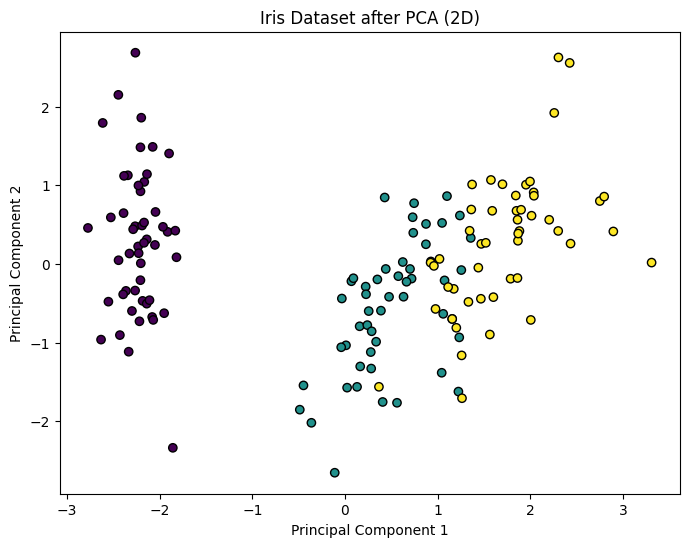


New Flower Prediction: virginica

Accuracy with k=3: 0.9555555555555556

Accuracy with k=7: 0.9555555555555556


In [1]:
# KNN Classification on Iris Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Step 2: Preprocessing
X = np.nan_to_num(X) # Handle missing values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Standardize features

# Step 3: PCA (2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# Step 5: Train KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 6: Predictions & Evaluation
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Step 7: Visualization after PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", edgecolor="k")
plt.title("Iris Dataset after PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Step 8: Predict new flower
new_flower = np.array([[5.8, 2.7, 5.1, 1.9]]) # New flower input
new_flower_scaled = scaler.transform(new_flower)
new_flower_pca = pca.transform(new_flower_scaled)
prediction = knn.predict(new_flower_pca)

print("\nNew Flower Prediction:", iris.target_names[prediction[0]])

# Step 9: Effect of different k values
for k in [3, 7]:
    knn_alt = KNeighborsClassifier(n_neighbors=k)
    knn_alt.fit(X_train, y_train)
    y_pred_alt = knn_alt.predict(X_test)
    print(f"\nAccuracy with k={k}: {accuracy_score(y_test, y_pred_alt)}")

C:\Users\milan\AppData\Local\Temp\ipykernel_16576\3606219531.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(companies, start="2022-01-01", end="2023-01-01")["Close"]
[*********************100%***********************]  6 of 6 completed



🔹 Financial Features:
         MeanReturn  Volatility
Ticker                        
AAPL     -0.001074    0.022471
AMZN     -0.002329    0.031571
GOOGL    -0.001689    0.024396
META     -0.003262    0.040555
MSFT     -0.001049    0.022289
TSLA     -0.003847    0.041155


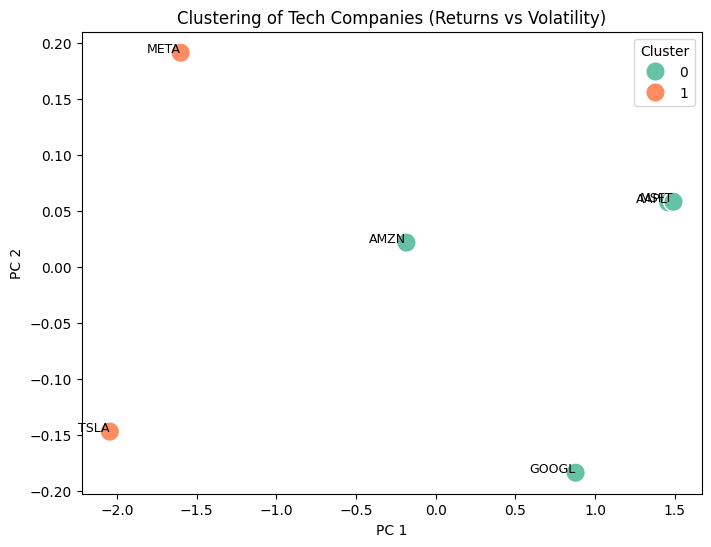


🔹 Clustering Results:
         MeanReturn  Volatility  Cluster
Ticker                                 
AAPL     -0.001074    0.022471        0
AMZN     -0.002329    0.031571        0
GOOGL    -0.001689    0.024396        0
META     -0.003262    0.040555        1
MSFT     -0.001049    0.022289        0
TSLA     -0.003847    0.041155        1


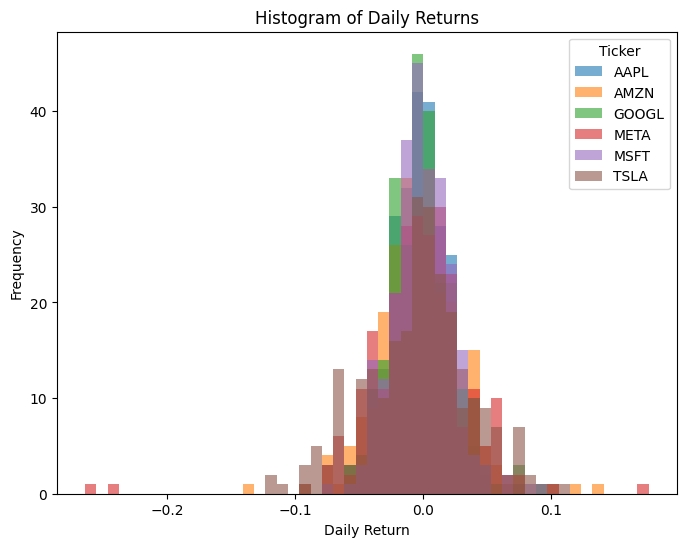

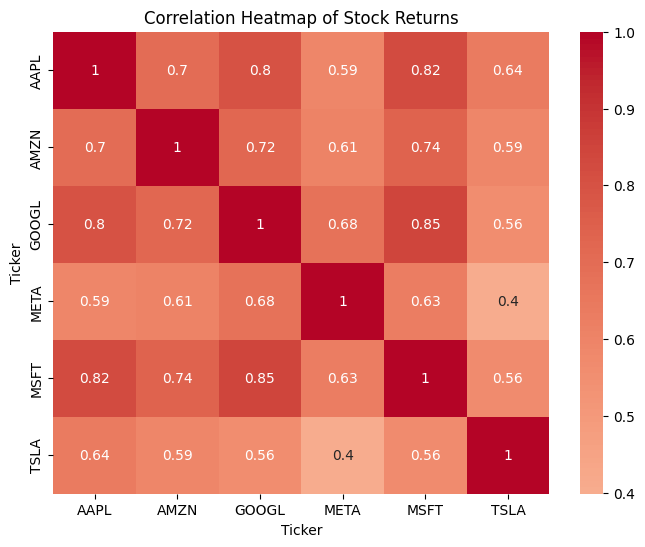

In [2]:
# Program 2: Financial Analysis using Clustering (Stock Market Data)
# Yahoo Finance stock dataset

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Step 1: Download stock data
companies = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META"]
data = yf.download(companies, start="2022-01-01", end="2023-01-01")["Close"]

# Step 2: Data Preprocessing
returns = data.pct_change().dropna() # Daily returns
mean_returns = returns.mean()
volatility = returns.std()

features = pd.DataFrame({
    "MeanReturn": mean_returns,
    "Volatility": volatility
})

print("\n🔹 Financial Features:\n", features)

# Step 3: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Step 4: Clustering (KMeans)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
features["Cluster"] = clusters

# Step 5: PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=features["Cluster"],
    s=200,
    palette="Set2"
)

# Add company labels near each point
for i, company in enumerate(features.index):
    plt.text(X_pca[i,0], X_pca[i,1], company, fontsize=9, ha="right")

plt.title("Clustering of Tech Companies (Returns vs Volatility)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

print("\n🔹 Clustering Results:\n", features)
# Histogram of daily returns for all companies
returns.plot(kind="hist", bins=50, figsize=(8,6), alpha=0.6)
plt.title("Histogram of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()
# Correlation heatmap of stock returns
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Stock Returns")
plt.show()